# Rate-All-That-Apply (RATA)
## Create a 100-row dataset sampled by descriptor-length and enriched with names.
## https://www.science.org/doi/10.1126/science.ade4401
## https://github.com/BioMachineLearning/openpom

In [1]:
import time
import urllib.parse
from typing import Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import requests

IN_CSV  = "Data/curated_GS_LF_merged_4983.csv"
OUT_CSV = "rata_100.csv"

RANDOM_SEED = 2025
TIMEOUT = 20
SLEEP   = 0.06  

PUBCHEM_PUG = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"

def count_desc(entry: object) -> int:
    """Count non-empty items split by ';'."""
    if entry is None:
        return 0
    s = str(entry)
    if not s.strip():
        return 0
    items = [x.strip() for x in s.split(";")]
    return sum(1 for x in items if x)

def ensure_columns(df: pd.DataFrame):
    needed = ["nonStereoSMILES", "descriptors"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise SystemExit(f"Missing required column(s): {missing}")

def smiles_present_mask(s: pd.Series) -> pd.Series:
    return (s.astype(str)
              .str.replace("\u00A0", " ", regex=False)
              .str.strip()
              .replace({"": np.nan, "NA": np.nan, "NaN": np.nan, "null": np.nan, "None": np.nan})
              .notna())

def build_options_column_names(columns: List[str]) -> str:
    """All column names except these two, joined by '; '."""
    ex = {"nonStereoSMILES", "descriptors"}
    kept = [c for c in columns if c not in ex]
    return "; ".join(kept)

SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "SMILES-to-Name/1.0 (local-script)"})

def name_from_smiles(smiles: str) -> Tuple[Optional[str], str]:
    """
    Query PubChem: /compound/smiles/{smiles}/property/Title,IUPACName
    Returns (name, note) where name = Title or IUPACName; note is diagnostic.
    """
    if not smiles:
        return None, "empty-smiles"
    url = (f"{PUBCHEM_PUG}/compound/smiles/"
           f"{urllib.parse.quote(smiles)}/property/Title,IUPACName/JSON")
    try:
        r = SESSION.get(url, timeout=TIMEOUT)
        if r.status_code != 200:
            return None, f"http{r.status_code}"
        j = r.json()
        props = j.get("PropertyTable", {}).get("Properties", [])
        if not props:
            return None, "no-props"
        p = props[0]
        title = (p.get("Title") or "").strip() or None
        iupac = (p.get("IUPACName") or "").strip() or None
        nm = title or iupac
        return nm, ("title" if title else ("iupac" if iupac else "none"))
    except requests.RequestException as e:
        return None, f"err:{e.__class__.__name__}"
    except ValueError:
        return None, "json-decode"

def map_names_for_smiles(smiles_list: List[str]) -> Dict[str, str]:
    unique = sorted(set([s for s in smiles_list if isinstance(s, str) and s.strip()]))
    out: Dict[str, str] = {}
    for i, smi in enumerate(unique, start=1):
        name, note = name_from_smiles(smi)
        out[smi] = name or ""
        print(f"[name {i}/{len(unique)}] SMILES→Name: {'OK' if name else 'MISS'} | {note}")
        time.sleep(SLEEP)
    return out

def main():
    rng = np.random.default_rng(RANDOM_SEED)

    df = pd.read_csv(IN_CSV)
    ensure_columns(df)

    mask_smiles = smiles_present_mask(df["nonStereoSMILES"])
    mask_desc   = df["descriptors"].astype(str).str.strip().ne("")
    df = df.loc[mask_smiles & mask_desc].copy()
    if df.empty:
        raise SystemExit("No usable rows after filtering for SMILES + descriptors.")

    df["desc_count"] = df["descriptors"].apply(count_desc)

    needs = {5: 25, 4: 25, 3: 25, 2: 25}
    picks: List[pd.DataFrame] = []

    for k, need in needs.items():
        pool = df.loc[df["desc_count"] == k]
        if len(pool) < need:
            raise SystemExit(f"Need {need} rows with {k} descriptor words, but found {len(pool)}.")
        picks.append(pool.sample(n=need, replace=False,
                                 random_state=int(rng.integers(0, 2**31-1))))

    selected = pd.concat(picks, ignore_index=True)

    name_map = map_names_for_smiles(selected["nonStereoSMILES"].astype(str).tolist())
    selected["compound.name_1"] = selected["nonStereoSMILES"].astype(str).map(lambda s: name_map.get(s, ""))

    options_val = build_options_column_names(list(df.columns))

    out = pd.DataFrame({
        "compound.name_1": selected["compound.name_1"].fillna(""),
        "SMILES_1": selected["nonStereoSMILES"].astype(str),
        "compound.name_2": "",     # left empty
        "SMILES_2": "",            # left empty
        "OPTIONS": options_val,
        "question_category": "rata",
        "answer": selected["descriptors"].astype(str),
        "other_info": "",          # left empty
    })

    def p1(row):
        return (f"Which of the following odor descriptors apply to molecule {row['SMILES_1']}? "
                f"Select all that apply from [{row['OPTIONS']}]. Do not write any comments.")
    def p2(row):
        name = row['compound.name_1'] if row['compound.name_1'] else "this compound"
        return (f"Which of the following odor descriptors apply to molecule {name}? "
                f"Select all that apply from [{row['OPTIONS']}]. Do not write any comments.")

    out["prompt.1"] = out.apply(p1, axis=1)
    out["prompt.2"] = out.apply(p2, axis=1)

    out = out[[
        "compound.name_1","SMILES_1",
        "compound.name_2","SMILES_2",
        "OPTIONS","question_category","prompt.1","prompt.2","answer","other_info"
    ]]

    out = out.sample(frac=1.0, replace=False, random_state=int(rng.integers(0, 2**31-1))).reset_index(drop=True)
    out.insert(0, "question_ID", np.arange(1, len(out) + 1, dtype=int))

    out.to_csv(OUT_CSV, index=False)
    print(f"Wrote {OUT_CSV} with {len(out)} rows "
          f"(25 each for descriptor counts 5,4,3,2).")

if __name__ == "__main__":
    main()


[name 1/100] SMILES→Name: OK | title
[name 2/100] SMILES→Name: OK | title
[name 3/100] SMILES→Name: OK | title
[name 4/100] SMILES→Name: OK | title
[name 5/100] SMILES→Name: OK | title
[name 6/100] SMILES→Name: OK | title
[name 7/100] SMILES→Name: OK | title
[name 8/100] SMILES→Name: OK | title
[name 9/100] SMILES→Name: OK | title
[name 10/100] SMILES→Name: OK | title
[name 11/100] SMILES→Name: OK | title
[name 12/100] SMILES→Name: OK | title
[name 13/100] SMILES→Name: OK | title
[name 14/100] SMILES→Name: OK | title
[name 15/100] SMILES→Name: OK | title
[name 16/100] SMILES→Name: OK | title
[name 17/100] SMILES→Name: OK | title
[name 18/100] SMILES→Name: OK | title
[name 19/100] SMILES→Name: OK | title
[name 20/100] SMILES→Name: OK | title
[name 21/100] SMILES→Name: OK | title
[name 22/100] SMILES→Name: OK | title
[name 23/100] SMILES→Name: OK | title
[name 24/100] SMILES→Name: OK | title
[name 25/100] SMILES→Name: OK | title
[name 26/100] SMILES→Name: OK | title
[name 27/100] SMILES→

Descriptive statistics for number of words in 'answer':
count    100.000000
mean       3.500000
std        1.123666
min        2.000000
25%        2.750000
50%        3.500000
75%        4.250000
max        5.000000
Name: answer_word_count, dtype: float64


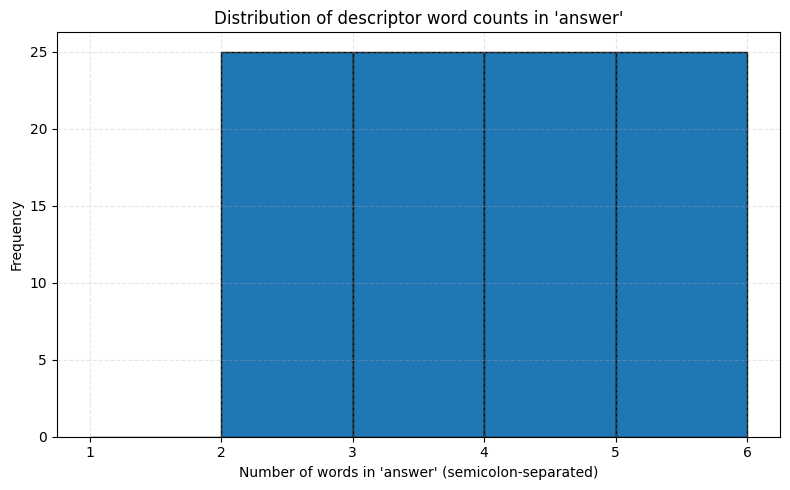

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

IN_CSV = "rata_100.csv"
ANSWER_COL = "answer"  
SAVE_PNG = True
OUT_PNG = "answer_wordcount_distribution.png"

def count_semicolon_words(val) -> int:
    if pd.isna(val):
        return 0
    s = str(val).replace("\u00A0", " ").strip()
    if not s:
        return 0
    tokens = [t.strip() for t in s.split(";")]
    return sum(1 for t in tokens if t)

def main():
    df = pd.read_csv(IN_CSV)

    if ANSWER_COL not in df.columns:
        raise SystemExit(f"Column '{ANSWER_COL}' not found. Available: {list(df.columns)}")

    df["answer_word_count"] = df[ANSWER_COL].apply(count_semicolon_words)

    print("Descriptive statistics for number of words in 'answer':")
    print(df["answer_word_count"].describe())

    wc = df["answer_word_count"]
    if wc.max() >= 1:
        bins = range(1, int(wc.max()) + 2)
        plot_vals = wc[wc >= 1]
    else:
        bins = [0, 1]
        plot_vals = wc

    plt.figure(figsize=(8, 5))
    plt.hist(plot_vals, bins=bins, edgecolor="black")
    plt.xlabel("Number of words in 'answer' (semicolon-separated)")
    plt.ylabel("Frequency")
    plt.title("Distribution of descriptor word counts in 'answer'")
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
